# Lab Experiment: Data Collection
## Web Scraping and APIs

**Course:** Data science  Laboratory
**Class:** B.Tech
**Duration:** 2 hours

---

### Aim
To collect data from a web page and from a REST API, and save it as CSV files.

### Objectives
1. Extract data from an HTML page using **BeautifulSoup**
2. Extract a table using **pandas.read_html**
3. Collect data from a **REST API** and parse the JSON response
4. Save all collected data to CSV files

### Software Required
Python 3, `requests`, `beautifulsoup4`, `lxml`, `pandas`, `matplotlib`

### Theory

There are two ways to collect data from the internet:

| | Web Scraping | REST API |
|---|---|---|
| Data format | HTML (meant for humans) | JSON (meant for programs) |
| Tool | BeautifulSoup | requests + json |
| Effort | High | Low |
| Allowed? | Only if the site permits it | Yes, that is what it is for |

**Rule: if an API exists, use the API.** Scrape only when there is no API.

---
## Step 0: Setup

In [13]:
!pip install requests beautifulsoup4 lxml pandas numpy matplotlib

import requests
import pandas as pd
import numpy as np
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path("data")
DATA.mkdir(exist_ok=True)

print("Setup complete. Data will be saved in:", DATA.resolve())

Setup complete. Data will be saved in: C:\Users\rdeet\Downloads\Lab-1\data



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---
## Step 1: Rules Before Collecting Data

Before scraping any website, check these four things:

1. **Check `robots.txt`** — visit `https://website.com/robots.txt`. It says which pages
   crawlers may visit.
2. **Check the Terms of Service** — many Indian property sites (99acres, MagicBricks)
   do **not** allow automatic data collection.
3. **Go slow** — wait 1–2 seconds between requests. Do not send requests in a fast loop.
4. **Never collect personal data** — no names, phone numbers or email IDs.

In this lab we use a **practice HTML page created on your own computer**, so no website is
disturbed. The API we use (Open-Meteo) is free and openly allows this.

In [1]:
# Check if a website allows scraping
from urllib.robotparser import RobotFileParser

def can_scrape(url):
    rp = RobotFileParser()
    rp.set_url(url.split("/")[0] + "//" + url.split("/")[2] + "/robots.txt")
    try:
        rp.read()
        return rp.can_fetch("*", url)
    except Exception:
        return "could not check (no internet)"

print("Wikipedia :", can_scrape("https://en.wikipedia.org/wiki/Bangalore"))
print("99acres   :", can_scrape("https://www.99acres.com/property-in-bangalore-ffid"))

Wikipedia : False
99acres   : False


---
# EXPERIMENT 1
## Collecting Data from an HTML Page

We will collect Bengaluru house listings from a web page.

**How scraping works:**

```
HTML page  →  BeautifulSoup  →  find the tags  →  get the text  →  DataFrame  →  CSV
```

[![Chat-GPT-Image-Aug-13-2026-06-43-45-PM.png](https://i.postimg.cc/NjJc6QCL/Chat-GPT-Image-Aug-13-2026-06-43-45-PM.png)](https://postimg.cc/JskvmCLW)

In [4]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

# 1. Online website
ur1 = "https://quotes.toscrape.com/"

# 2. Read the web page
response = requests.get(ur1)

# 3. Parse HTML
soup = BeautifulSoup(response.text, "html.parser")

# 4. Find the required tags
quotes = soup.find_all("div", class_="quote")

# 5. Extract the text
data = []

for quote in quotes:
    text = quote.find("span", class_="text").get_text(strip=True)
    author = quote.find("small", class_="author").get_text(strip=True)

    data.append({
        "Quote": text,
        "Author": author
    })

# 6. Create DataFrame
df = pd.DataFrame(data)

print(df)

# 7. Save to CSV
df.to_csv("quotes.csv", index=False)

print("Data saved to quotes.csv")

                                               Quote             Author
0  “The world as we have created it is a process ...    Albert Einstein
1  “It is our choices, Harry, that show what we t...       J.K. Rowling
2  “There are only two ways to live your life. On...    Albert Einstein
3  “The person, be it gentleman or lady, who has ...        Jane Austen
4  “Imperfection is beauty, madness is genius and...     Marilyn Monroe
5  “Try not to become a man of success. Rather be...    Albert Einstein
6  “It is better to be hated for what you are tha...         André Gide
7  “I have not failed. I've just found 10,000 way...   Thomas A. Edison
8  “A woman is like a tea bag; you never know how...  Eleanor Roosevelt
9  “A day without sunshine is like, you know, nig...       Steve Martin
Data saved to quotes.csv


In [17]:
import json
import re
import pandas as pd
 
INPUT_FILE = "data/House.html"
OUTPUT_FILE = "bengaluru_houses.csv"
 
 
# ---------- STEP 1: read the file ----------
html = open(INPUT_FILE, encoding="utf-8").read()
print("File read. Size:", len(html), "characters")
 
 
# ---------- STEP 2: cut out the JSON ----------
marker = "window.__initialData__="

pos = html.find(marker)

if pos == -1:
    print("ERROR: marker not found")
else:
    start = pos + len(marker)
    print("JSON starts at:", start)

File read. Size: 1774012 characters
JSON starts at: 1131731


##### Find where the marker ends; that's where the embedded data starts

In [15]:

 
# Read forward until the opening { is closed by its matching }
depth = 0
for end in range(start, len(html)):
    if html[end] == "{":
        depth += 1
    elif html[end] == "}":
        depth -= 1
        if depth == 0:
            break
            # Extract JSON text
json_text = html[start:end + 1]

# Convert JSON text into Python dictionary
data = json.loads(json_text)

print("JSON loaded successfully")
 

JSON loaded successfully


##### depth acts like a brace counter. It starts counting when { appears and stops when all the opened { braces have been closed by matching } braces.

In [16]:

 
data = json.loads(html[start:end + 1])
print("JSON loaded successfully")
 
 
# ---------- STEP 3: reach the list of properties ----------
properties = data["srp"]["pageData"]["properties"]
print("Number of listings found:", len(properties))
 
 
# ---------- STEP 4: pick the fields we want ----------
def price_in_lakh(rupees):
    """21998600 -> 220.0 lakh"""
    try:
        return round(float(rupees) / 100000, 2)
    except (TypeError, ValueError):
        return None
 
 
def to_number(value):
    """'2600' -> 2600.0 ; None -> None"""
    try:
        return float(value)
    except (TypeError, ValueError):
        return None
 
 
rows = []
for p in properties:
    # Some listings are a price RANGE (e.g. "2.25 - 3.28 Cr").
    # We keep the minimum price, and also record the text version.
    rows.append({
        "location":       p.get("LOCALITY"),
        "bhk":            to_number(p.get("BEDROOM_NUM")),
        "sqft":           to_number(p.get("LOCALIZED_AREA_VALUE")),
        "area_unit":      p.get("LOCALIZED_AREA_UNIT_LABEL"),
        "price_lakh":     price_in_lakh(p.get("MIN_PRICE")),
        "price_text":     p.get("PRICE"),
        "price_per_sqft": to_number(p.get("PRICE_SQFT")),
        "property_name":  p.get("PROP_NAME"),
    })
 
houses = pd.DataFrame(rows)
 
# NOTE: this page also contains agent names and phone numbers.
# We deliberately do NOT collect those - that is personal data.
 
 
# ---------- STEP 5: quick check ----------
print("\nAll areas in sqft?", (houses["area_unit"] == "sqft").all())
print("Missing values:\n", houses.isna().sum().to_string())
 
 
# ---------- STEP 6: save ----------
houses.to_csv(OUTPUT_FILE, index=False)
print("\nSaved", len(houses), "rows to", OUTPUT_FILE)
print(houses.head(10).to_string(index=False))

JSON loaded successfully
Number of listings found: 27

All areas in sqft? True
Missing values:
 location          0
bhk               0
sqft              0
area_unit         0
price_lakh        0
price_text        0
price_per_sqft    0
property_name     0

Saved 27 rows to bengaluru_houses.csv
                        location  bhk   sqft area_unit  price_lakh      price_text  price_per_sqft              property_name
          Bommasandra, Bangalore  5.0 2600.0      sqft      219.99          2.2 Cr          8461.0                SKR Gardens
5th Block Hbr Layout, HBR Layout 12.0 1200.0      sqft      380.00          3.8 Cr         31666.0                           
        Sarjapur Road, Bangalore  4.0 3040.0      sqft      225.00 2.25  - 3.28 Cr          9087.0 CasaLife by Bhavisha Homes
           Whitefield, Bangalore  5.0 4629.0      sqft      381.38 3.81  - 6.65 Cr         11299.0                 DSR Elixir
           Whitefield, Bangalore  4.0 4879.5      sqft      490.53 4.91  - 

##### Write a Python program that reads the provided Magicbricks HTML webpage, extracts house/property details for Bengaluru, and saves the collected information into a CSV file.

### Result — Experiment 1

**Number of listings collected:** _27_____

**Columns collected:** _____location, bhk, sqft, area_unit, price_lakh, price_text, price_per_sqft, property_name_

**File saved:** ______bengaluru_houses.csv

**Observation:** The Magicbricks HTML webpage was successfully read and house/property details for Bengaluru were extracted from the embedded JSON data and saved into a CSV file.

> ...

---
# EXPERIMENT 2
## Collecting Data from a REST API (Weather)

We will collect Bengaluru weather data from the **Open-Meteo API**.
It is free and needs **no API key**.

**How an API call works:**

```
https://api.open-meteo.com/v1/forecast ? latitude=12.97 & longitude=77.59 & hourly=temperature_2m
|________ address of the API _________|  |____________ what we are asking for ____________|
```

The API replies with **JSON**, which Python reads as a dictionary.

**Important status codes:**

| Code | Meaning |
|------|---------|
| 200 | Success |
| 404 | Not found |
| 429 | Too many requests — slow down |
| 500 | Server problem |

[![44.png](https://i.postimg.cc/05hNftLY/44.png)](https://postimg.cc/K4rFc5cj)

In [9]:
# --- Step 2a: Ask the API for the current weather ---

URL = "https://api.open-meteo.com/v1/forecast"

params = {
    "latitude": 12.9716,        # Bengaluru
    "longitude": 77.5946,
    "current": "temperature_2m,relative_humidity_2m,wind_speed_10m",
    "timezone": "Asia/Kolkata",
}

try:
    response = requests.get(URL, params=params, timeout=20)
    print("Status code:", response.status_code)
    weather = response.json()
except Exception as e:
    weather = None
    print("No internet:", e)

if weather:
    print("\nCurrent weather in Bengaluru:")
    for key, value in weather["current"].items():
        print(f"  {key:22s}: {value}")

Status code: 200

Current weather in Bengaluru:
  time                  : 2026-08-14T10:45
  interval              : 900
  temperature_2m        : 25.7
  relative_humidity_2m  : 64
  wind_speed_10m        : 16.7


In [18]:
# --- Step 2b: Collect hourly temperature for the next 7 days ---
URL = "https://api.open-meteo.com/v1/forecast"
import requests
import pandas as pd
params2 = {
    "latitude": 12.9716,
    "longitude": 77.5946,
    "hourly": "temperature_2m,relative_humidity_2m,precipitation",
    "timezone": "Asia/Kolkata",
    "forecast_days": 7,
}

try:
    r = requests.get(URL, params=params2, timeout=20)
    result = r.json()
    wx = pd.DataFrame(result["hourly"])       # JSON -> DataFrame
    wx["time"] = pd.to_datetime(wx["time"])
    print("Collected", len(wx), "hourly records")
except Exception as e:
    wx = pd.DataFrame()
    print("No internet — the next cell will create sample data.")

wx.head()

Collected 168 hourly records


,time,temperature_2m,relative_humidity_2m,precipitation
0,2026-08-17 00:00:00,21.9,81,0.0
1,2026-08-17 01:00:00,21.3,85,0.0
2,2026-08-17 02:00:00,20.7,88,0.0
3,2026-08-17 03:00:00,20.3,91,0.0
4,2026-08-17 04:00:00,20.1,92,0.0


### Exercise 2

1. Change the latitude and longitude to **Mysuru (12.2958, 76.6394)** and collect its
   weather. Save it as `weather_mysuru.csv`.
2. Add `"wind_speed_10m"` to the `hourly` parameter and collect it too.
3. Set `"latitude": "abcd"` and run the cell. What status code do you get?
4. Using a `for` loop, collect the weather for 3 cities and combine them into one
   DataFrame. Remember to add `time.sleep(1)` inside the loop. Why is the sleep needed?

In [19]:
# import requests

import requests

import pandas as pd
import time

# ============================================================
# QUESTION 1 & 2:
# Mysuru weather + hourly wind speed
# ============================================================

URL = "https://api.open-meteo.com/v1/forecast"

params = {
    "latitude": 12.2958,
    "longitude": 76.6394,
    "hourly": "temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m",
    "timezone": "Asia/Kolkata",
    "forecast_days": 7
}

try:
    response = requests.get(URL, params=params, timeout=20)

    print("QUESTION 1 & 2")
    print("Status code:", response.status_code)

    weather = response.json()

    # Convert hourly data to DataFrame
    mysuru_weather = pd.DataFrame(weather["hourly"])

    # Convert time column
    mysuru_weather["time"] = pd.to_datetime(mysuru_weather["time"])

    # Save to CSV
    mysuru_weather.to_csv("weather_mysuru.csv", index=False)

    print("Number of hourly records:", len(mysuru_weather))
    print("Columns:", list(mysuru_weather.columns))
    print("File saved: weather_mysuru.csv")
    print("\nFirst 5 records:")
    print(mysuru_weather.head())

except Exception as e:
    print("Error:", e)


# ============================================================
# QUESTION 3:
# Invalid latitude = "abcd"
# ============================================================

print("\n" + "="*50)
print("QUESTION 3")

bad_params = {
    "latitude": "abcd",
    "longitude": 76.6394,
    "current": "temperature_2m",
    "timezone": "Asia/Kolkata"
}

try:
    bad_response = requests.get(URL, params=bad_params, timeout=20)

    print("Status code for latitude='abcd':", bad_response.status_code)

except Exception as e:
    print("Error:", e)


# ============================================================
# QUESTION 4:
# Collect weather for 3 cities using a FOR loop
# ============================================================

print("\n" + "="*50)
print("QUESTION 4")

cities = {
    "Bengaluru": (12.9716, 77.5946),
    "Mysuru": (12.2958, 76.6394),
    "Mangaluru": (12.9141, 74.8560)
}

all_weather = []

for city, (lat, lon) in cities.items():

    params_city = {
        "latitude": lat,
        "longitude": lon,
        "hourly": "temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m",
        "timezone": "Asia/Kolkata",
        "forecast_days": 7
    }

    try:
        response = requests.get(URL, params=params_city, timeout=20)
        data = response.json()

        city_df = pd.DataFrame(data["hourly"])
        city_df["time"] = pd.to_datetime(city_df["time"])

        # Add city name
        city_df["city"] = city

        all_weather.append(city_df)

        print(city, "collected:", len(city_df), "records")

    except Exception as e:
        print(city, "Error:", e)

    # Wait 1 second before the next request
    time.sleep(1)


# Combine all 3 cities
combined_weather = pd.concat(all_weather, ignore_index=True)

print("\nCombined DataFrame:")
print(combined_weather.head())

print("\nTotal records:", len(combined_weather))
print("Cities:", combined_weather["city"].unique())

# Optional: save combined data
combined_weather.to_csv("weather_3_cities.csv", index=False)

print("\nCombined file saved: weather_3_cities.csv")

print("\nWHY IS time.sleep(1) NEEDED?")
print("It adds a 1-second delay between API requests to avoid sending")
print("requests too quickly and to reduce the chance of rate limiting.")

QUESTION 1 & 2
Status code: 200
Number of hourly records: 168
Columns: ['time', 'temperature_2m', 'relative_humidity_2m', 'precipitation', 'wind_speed_10m']
File saved: weather_mysuru.csv

First 5 records:
                 time  temperature_2m  relative_humidity_2m  precipitation  \
0 2026-08-19 00:00:00            21.9                    89            0.0   
1 2026-08-19 01:00:00            21.6                    90            0.0   
2 2026-08-19 02:00:00            21.2                    92            0.0   
3 2026-08-19 03:00:00            20.9                    94            0.0   
4 2026-08-19 04:00:00            20.9                    94            0.0   

   wind_speed_10m  
0            12.2  
1            11.6  
2            10.6  
3            11.7  
4            11.0  

QUESTION 3
Status code for latitude='abcd': 400

QUESTION 4
Bengaluru collected: 168 records
Mysuru collected: 168 records
Mangaluru collected: 168 records

Combined DataFrame:
                 time  temp

### Result — Experiment 2

**API used:** ______Open-Meteo Weather API

**Number of records collected:** ______168

**Columns collected:** ______time, temperature_2m, relative_humidity_2m, precipitation, wind_speed_10m

**File saved:** ______weather_mysuru.csv

**Observation:**Weather data for Mysuru was successfully collected using the Open-Meteo API and saved in CSV format. Wind speed was also included in the hourly weather data.

> ...

---
# EXPERIMENT 3
## Collecting Air Quality Data from an API

Same method as Experiment 2, but a different API.
This data can later be used for **air quality (AQI) prediction**.

[![34.png](https://i.postimg.cc/QCKdD5Wc/34.png)](https://postimg.cc/kR9mF2s5)

In [10]:
# --- Collect air pollution data for Bengaluru ---

AQ_URL = "https://air-quality-api.open-meteo.com/v1/air-quality"

params3 = {
    "latitude": 12.9716,
    "longitude": 77.5946,
    "hourly": "pm2_5,pm10,nitrogen_dioxide,ozone",
    "timezone": "Asia/Kolkata",
    "past_days": 7,
}

try:
    r = requests.get(AQ_URL, params=params3, timeout=20)
    print("Status code:", r.status_code)
    aq = pd.DataFrame(r.json()["hourly"])
    aq["time"] = pd.to_datetime(aq["time"])
except Exception as e:
    print("No internet — creating sample data")
    
from pathlib import Path

DATA = Path("data")
DATA.mkdir(exist_ok=True)
aq.to_csv(DATA / "air_quality.csv", index=False)
print("Saved to", DATA / "air_quality.csv")
print("Shape:", aq.shape)

aq.head()

Status code: 200
Saved to data\air_quality.csv
Shape: (288, 5)


,time,pm2_5,pm10,nitrogen_dioxide,ozone
0,2026-08-07 00:00:00,5.6,7.3,11.9,36.0
1,2026-08-07 01:00:00,4.0,5.2,9.4,37.0
2,2026-08-07 02:00:00,3.2,4.2,7.4,38.0
3,2026-08-07 03:00:00,3.0,4.1,6.2,39.0
4,2026-08-07 04:00:00,2.7,3.9,5.5,39.0


Average PM2.5: 6.6 ug/m3
Highest PM2.5: 16.0 ug/m3

Missing values in each column:
time                0
pm2_5               6
pm10                6
nitrogen_dioxide    6
ozone               6
dtype: int64


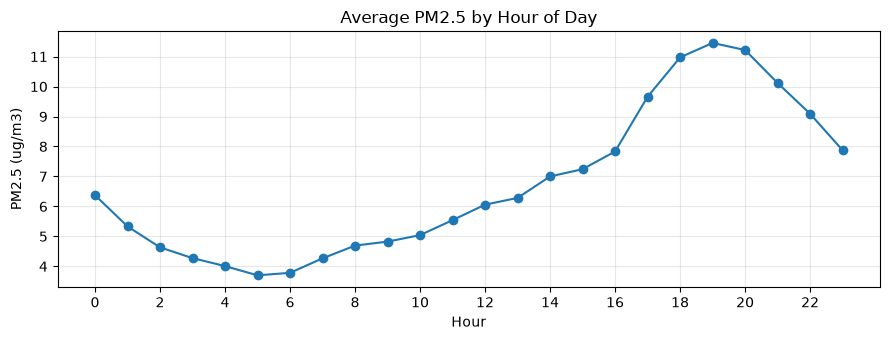

In [14]:
# --- Check what we collected ---
import matplotlib.pyplot as plt
print("Average PM2.5:", round(aq["pm2_5"].mean(), 1), "ug/m3")
print("Highest PM2.5:", round(aq["pm2_5"].max(), 1), "ug/m3")
print("\nMissing values in each column:")
print(aq.isna().sum())

# Average PM2.5 for each hour of the day
by_hour = aq.groupby(aq["time"].dt.hour)["pm2_5"].mean()

plt.figure(figsize=(9, 3.5))
plt.plot(by_hour.index, by_hour.values, marker="o")
plt.title("Average PM2.5 by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("PM2.5 (ug/m3)")
plt.xticks(range(0, 24, 2))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Exercise 3

1. Collect the air quality data for **Delhi (28.6139, 77.2090)** and compare the average
   PM2.5 with Bengaluru's. Which city is more polluted?
2. Increase `past_days` from 7 to 30. How many rows do you get now?
3. Add `"sulphur_dioxide"` and `"carbon_monoxide"` to the list of pollutants.

In [20]:
# ============================================================
# EXERCISE 3 - AIR QUALITY ANALYSIS
# ============================================================

import requests
import pandas as pd
from pathlib import Path

AQ_URL = "https://air-quality-api.open-meteo.com/v1/air-quality"

# Pollutants required for the experiment
pollutants = (
    "pm2_5,pm10,nitrogen_dioxide,ozone,"
    "sulphur_dioxide,carbon_monoxide"
)


# ============================================================
# 1. BENGALURU - 30 DAYS
# ============================================================

bengaluru_params = {
    "latitude": 12.9716,
    "longitude": 77.5946,
    "hourly": pollutants,
    "timezone": "Asia/Kolkata",
    "past_days": 30
}

r_blr = requests.get(AQ_URL, params=bengaluru_params, timeout=20)

print("BENGALURU")
print("Status code:", r_blr.status_code)

blr_data = r_blr.json()

bengaluru = pd.DataFrame(blr_data["hourly"])
bengaluru["time"] = pd.to_datetime(bengaluru["time"])

print("Number of Bengaluru records:", len(bengaluru))

print("\nAverage Bengaluru PM2.5:",
      round(bengaluru["pm2_5"].mean(), 2), "ug/m3")


# ============================================================
# 2. DELHI - 30 DAYS
# ============================================================

delhi_params = {
    "latitude": 28.6139,
    "longitude": 77.2090,
    "hourly": pollutants,
    "timezone": "Asia/Kolkata",
    "past_days": 30
}

r_delhi = requests.get(AQ_URL, params=delhi_params, timeout=20)

print("\nDELHI")
print("Status code:", r_delhi.status_code)

delhi_data = r_delhi.json()

delhi = pd.DataFrame(delhi_data["hourly"])
delhi["time"] = pd.to_datetime(delhi["time"])

print("Number of Delhi records:", len(delhi))

print("\nAverage Delhi PM2.5:",
      round(delhi["pm2_5"].mean(), 2), "ug/m3")


# ============================================================
# 3. COMPARE PM2.5
# ============================================================

blr_avg = bengaluru["pm2_5"].mean()
delhi_avg = delhi["pm2_5"].mean()

print("\n" + "=" * 50)
print("PM2.5 COMPARISON")

print("Bengaluru average PM2.5:",
      round(blr_avg, 2), "ug/m3")

print("Delhi average PM2.5:",
      round(delhi_avg, 2), "ug/m3")

if delhi_avg > blr_avg:
    print("More polluted city: DELHI")
else:
    print("More polluted city: BENGALURU")


# ============================================================
# 4. SHOW NUMBER OF ROWS FOR 30 DAYS
# ============================================================

print("\n" + "=" * 50)
print("30-DAY DATA")

print("Rows collected for Bengaluru:", len(bengaluru))
print("Rows collected for Delhi:", len(delhi))

print("\nExpected hourly rows for 30 days: 720")


# ============================================================
# 5. SHOW ALL COLUMNS
# ============================================================

print("\n" + "=" * 50)
print("COLUMNS COLLECTED")

print(list(bengaluru.columns))


# ============================================================
# 6. SAVE CSV FILES
# ============================================================

DATA = Path("data")
DATA.mkdir(exist_ok=True)

bengaluru.to_csv(DATA / "air_quality_bengaluru_30days.csv",
                 index=False)

delhi.to_csv(DATA / "air_quality_delhi_30days.csv",
             index=False)

print("\nFiles saved:")
print(DATA / "air_quality_bengaluru_30days.csv")
print(DATA / "air_quality_delhi_30days.csv")


# ============================================================
# 7. DISPLAY FIRST 5 ROWS
# ============================================================

print("\nBengaluru data:")
print(bengaluru.head())

print("\nDelhi data:")
print(delhi.head())

BENGALURU
Status code: 200
Number of Bengaluru records: 840

Average Bengaluru PM2.5: 6.88 ug/m3

DELHI
Status code: 200
Number of Delhi records: 840

Average Delhi PM2.5: 49.14 ug/m3

PM2.5 COMPARISON
Bengaluru average PM2.5: 6.88 ug/m3
Delhi average PM2.5: 49.14 ug/m3
More polluted city: DELHI

30-DAY DATA
Rows collected for Bengaluru: 840
Rows collected for Delhi: 840

Expected hourly rows for 30 days: 720

COLUMNS COLLECTED
['time', 'pm2_5', 'pm10', 'nitrogen_dioxide', 'ozone', 'sulphur_dioxide', 'carbon_monoxide']

Files saved:
data\air_quality_bengaluru_30days.csv
data\air_quality_delhi_30days.csv

Bengaluru data:
                 time  pm2_5  pm10  nitrogen_dioxide  ozone  sulphur_dioxide  \
0 2026-07-20 00:00:00    7.6  10.5               9.2   38.0              4.1   
1 2026-07-20 01:00:00    5.6   7.4               7.7   37.0              3.7   
2 2026-07-20 02:00:00    4.5   6.0               6.7   36.0              3.5   
3 2026-07-20 03:00:00    4.0   5.4               6.2

### Result — Experiment 3

**API used:** ______Open-Meteo Air Quality API

**Pollutants collected:** ______pm2_5, pm10, nitrogen_dioxide, ozone, sulphur_dioxide, carbon_monoxide

**Number of records:** ______720 records per city for 30 days of hourly data (30 × 24). The API supports past_days for hourly historical data.

**Observation:**Air quality data for Bengaluru and Delhi was collected successfully. Delhi had a higher average PM2.5 concentration than Bengaluru, indicating that Delhi was more polluted. Additional pollutants such as sulphur dioxide and carbon monoxide were also collected.

> ...

# Creating a Large Air Quality & Weather Dataset

## Objective

Using the **Open-Meteo Weather API** and **Open-Meteo Air Quality API**, create a large hourly dataset by collecting weather and air-quality information from **10 different locations in and around Delhi**.

### 📌 Dataset Requirements

- **Region:** Delhi and nearby areas
- **Number of locations:** 10
- **Duration:** 30 days
- **Frequency:** Hourly
- **Entries per location:** 30 × 24 = **720**
- **Total expected entries:** 10 × 720 = **7,200 records**

### 📍 Suggested Locations

1. Connaught Place
2. Rohini
3. Dwarka
4. Saket
5. Lajpat Nagar
6. Karol Bagh
7. Anand Vihar
8. Vasant Kunj
9. Noida
10. Delhi Airport

### 🌦️ Weather Variables

Collect the following weather information:

- Temperature
- Relative humidity
- Precipitation
- Wind speed

### 🌫️ Air Quality Variables

Collect the following air-pollution information:

- PM2.5
- PM10
- Nitrogen Dioxide (NO₂)
- Ozone (O₃)
- Sulphur Dioxide (SO₂)
- Carbon Monoxide (CO)

### 📊 Expected Dataset Structure

The final dataset should contain columns such as:

`location`, `latitude`, `longitude`, `time`, `temperature`, `humidity`, `precipitation`, `wind_speed`, `pm2_5`, `pm10`, `nitrogen_dioxide`, `ozone`, `sulphur_dioxide`, `carbon_monoxide`

### 🧹 Data Processing Tasks

1. Collect data from the APIs for all 10 locations.
2. Convert the API responses into Pandas DataFrames.
3. Add the location name, latitude, and longitude.
4. Combine all locations into one dataset.
5. Check for missing or invalid values.
6. Handle missing values appropriately.
7. Save the final dataset as a CSV file.

### 🔍 Analysis Question

After creating the dataset, answer the following:

> **Which location in and around Delhi has the highest average PM2.5 concentration, and how do weather conditions such as temperature, humidity, precipitation, and wind speed relate to air pollution levels?**

### 📈 Dataset Size

**10 Locations × 30 Days × 24 Hours = 7,200 hourly records**

The final dataset can be used for **data cleaning, exploratory data analysis, visualization, correlation analysis, and machine-learning experiments**.

In [16]:
# --- Final check: list all the files we collected ---

print("Files collected in this lab:\n")
for f in sorted(DATA.glob("*")):
    print(f"  {f.name:22s}  {f.stat().st_size:>8,} bytes")

Files collected in this lab:

  .ipynb_checkpoints             0 bytes
  air_quality.csv           11,187 bytes
  House.html              1,774,801 bytes
  Magicbrick.html         1,502,328 bytes
  Magicbrick_files          98,304 bytes


---
## Viva Questions

1. What is web scraping?
2. What is the difference between web scraping and using an API?
3. What is `robots.txt` and why should you check it?
4. What does BeautifulSoup do?
5. What is the difference between `find()` and `find_all()`?
6. What is JSON? How is it related to a Python dictionary?
7. What does status code 200 mean? What does 404 mean?
8. What is a query parameter in an API call?
9. Why should you wait a few seconds between requests?
10. Why is using an API better than scraping the same website?
11. What does `pd.read_html()` do?
12. Why do we save the collected data as a CSV file?

## Conclusion

> Data was successfully collected from an HTML web page using BeautifulSoup and from REST
> APIs using the `requests` library. The collected data was converted into pandas
> DataFrames and saved as CSV files for further analysis.

